In [1]:
# Simple blue-percentage calculator for images in a folder
import os, glob, sys, subprocess

# ensure libs
try:
    import cv2, numpy as np, pandas as pd
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "opencv-python-headless numpy pandas"])
    import cv2, numpy as np, pandas as pd

folder = r"d:\aguadoce\ImagensVNSP"
patterns = ("*.jpg", "*.jpeg", "*.png", "*.tif", "*.tiff")
files = []
for p in patterns:
    files += glob.glob(os.path.join(folder, p))
files = sorted(files)

# HSV range for blue (tweak H,S,V as needed)
lower_blue = np.array([80,30,20], dtype=np.uint8)
upper_blue = np.array([170,255,255], dtype=np.uint8)

results = []
for fp in files:
    img = cv2.imread(fp)
    if img is None:
        continue
    h, w = img.shape[:2]
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, lower_blue, upper_blue)
    # cleanup small noise
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
    blue_pixels = int((mask > 0).sum())
    total_pixels = w * h
    pct_blue = 100.0 * blue_pixels / total_pixels if total_pixels else 0.0
    results.append({"file": os.path.basename(fp), "percent_blue": pct_blue, "blue_pixels": blue_pixels, "total_pixels": total_pixels})

# save and print summary
if results:
    df = pd.DataFrame(results)
    out_csv = os.path.join(folder, "blue_percent_results.csv")
    df.to_csv(out_csv, index=False)
    print("Saved:", out_csv)
    print(df)
else:
    print("No images found in", folder)

Saved: d:\aguadoce\ImagensVNSP\blue_percent_results.csv
              file  percent_blue  blue_pixels  total_pixels
0     VNSP2009.jpg     16.042804        33627        209608
1    VNSP2009c.jpg     37.045920        75996        205140
2   VNSP2009c2.jpg     38.421032        79019        205666
3     VNSP2012.jpg      0.000000            0        208683
4     VNSP2016.jpg     25.007409        52319        209214
5     VNSP2017.jpg     21.147810        43795        207090
6     VNSP2018.jpg      0.705262         1456        206448
7     VNSP2019.jpg      1.314549         2719        206839
8     VNSP2020.jpg      0.212888          442        207621
9     VNSP2021.jpg      0.273643          566        206839
10    VNSP2022.jpg     18.540996        38035        205140
11    VNSP2025.jpg     27.518411        57134        207621


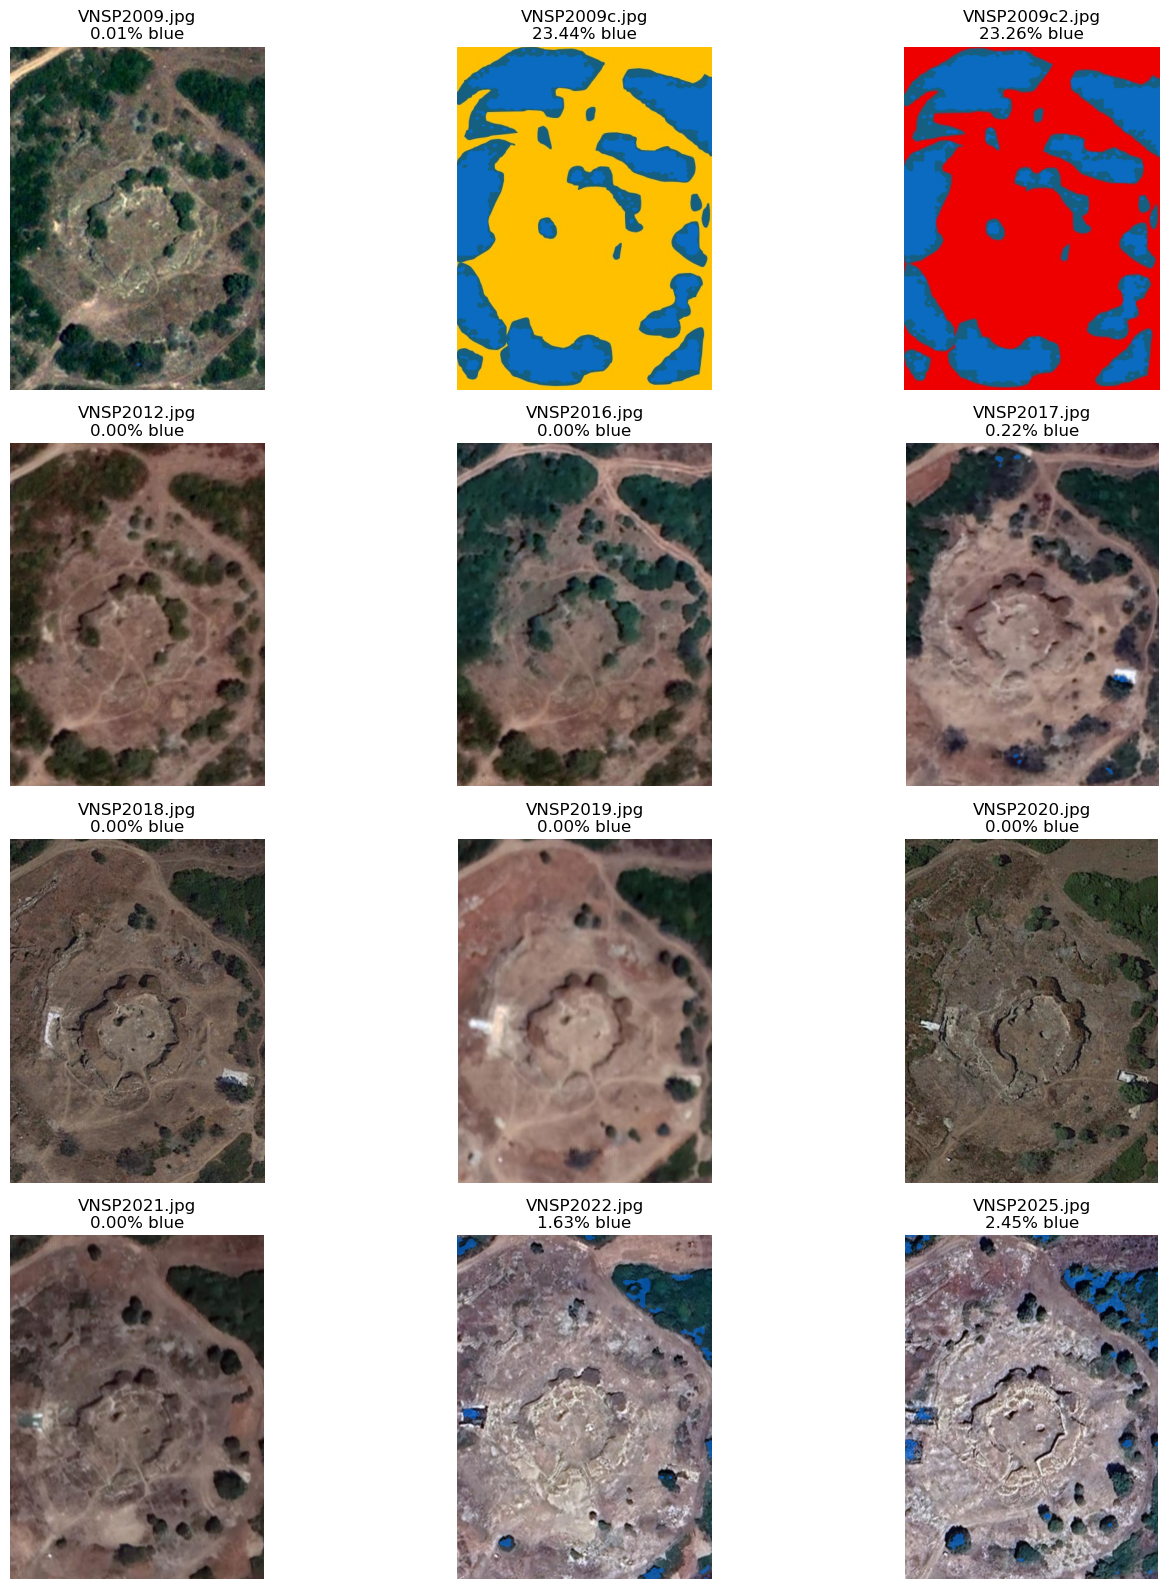

In [2]:
import math
import matplotlib.pyplot as plt

# ensure matplotlib installed in notebook (optional)
try:
    import matplotlib.pyplot as plt
except Exception:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
    import matplotlib.pyplot as plt

# Parameters: how many thumbnails to show (0 = show all)
n_show = 12

# reuse same folder / patterns or use results/files from above if present
# if 'files' is already defined in the notebook it will be used, otherwise rebuild it.
try:
    files
except NameError:
    files = []
    for p in ("*.jpg","*.jpeg","*.png","*.tif","*.tiff"):
        files += glob.glob(os.path.join(folder, p))
    files = sorted(files)

# HSV blue range used previously (tweak if needed)
lower_blue = np.array([100, 80, 50], dtype=np.uint8)
upper_blue = np.array([140, 255, 255], dtype=np.uint8)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))

to_display = files if (n_show == 0) else files[:min(n_show, len(files))]
if len(to_display) == 0:
    print("No images to display.")
else:
    cols = 3
    rows = math.ceil(len(to_display) / cols)
    plt.figure(figsize=(5*cols, 4*rows))
    for i, fp in enumerate(to_display):
        img = cv2.imread(fp)
        if img is None:
            continue
        h, w = img.shape[:2]
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        mask = cv2.inRange(hsv, lower_blue, upper_blue)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)

        blue_pixels = int((mask > 0).sum())
        total_pixels = w * h
        pct_blue = 100.0 * blue_pixels / total_pixels if total_pixels else 0.0

        # create overlay (RGB) - color masked pixels in bright blue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        overlay = img_rgb.copy()
        blue_color = np.array([0, 120, 255], dtype=np.uint8)  # BGR-like blue in RGB
        overlay[mask > 0] = (0.5 * overlay[mask > 0] + 0.5 * blue_color).astype(np.uint8)

        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(overlay)
        ax.set_title(f"{os.path.basename(fp)}\n{pct_blue:.2f}% blue")
        ax.axis("off")
    plt.tight_layout()
    plt.show()